### SVM Kernels Understanding

In [1]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-5.0, 5.0, 100)
y = np.sqrt(10*2 - x**2)
y = np.hstack([y, -y])
x= np.hstack([x, -x])

x1 = np.linspace(-5.0, 5.0, 100)
y1 = np.sqrt(4*2 - x1**2)
y1 = np.hstack([y1, -y1])
x1 = np.hstack([x1, -x1])


C:\Users\mouni\AppData\Local\Temp\ipykernel_15952\1430332263.py:5: RuntimeWarning: invalid value encountered in sqrt
  y = np.sqrt(10*2 - x**2)
C:\Users\mouni\AppData\Local\Temp\ipykernel_15952\1430332263.py:10: RuntimeWarning: invalid value encountered in sqrt
  y1 = np.sqrt(4*2 - x1**2)


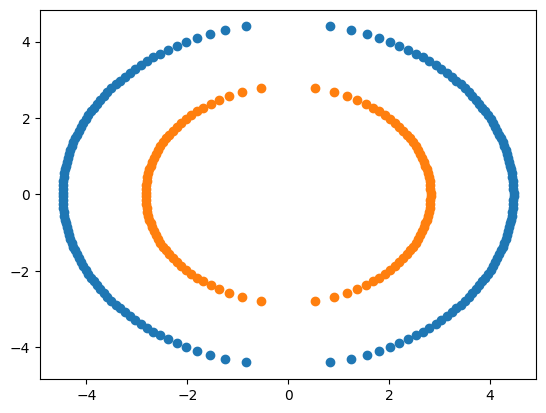

In [2]:
plt.scatter(x=y, y=x)
plt.scatter(x=y1, y=x1)

In [3]:
np.vstack([y,x])

array([[        nan,         nan,         nan,         nan,         nan,
                nan,  0.83264434,  1.25329888,  1.55814425,  1.80678245,
         2.02007575,  2.20828966,  2.37738812,  2.53120511,  2.67238062,
         2.80282555,  2.92397637,  3.03694558,  3.14261564,  3.24170041,
         3.33478695,  3.42236473,  3.50484673,  3.58258493,  3.65588196,
         3.72499999,  3.79016766,  3.85158548,  3.9094302 ,  3.96385825,
         4.01500857,  4.06300497,  4.10795799,  4.14996653,  4.18911918,
         4.22549532,  4.2591661 ,  4.29019521,  4.31863959,  4.34455001,
         4.36797157,  4.3889441 ,  4.40750258,  4.42367738,  4.43749457,
         4.44897611,  4.45814006,  4.46500067,  4.46956857,  4.47185076,
         4.47185076,  4.46956857,  4.46500067,  4.45814006,  4.44897611,
         4.43749457,  4.42367738,  4.40750258,  4.3889441 ,  4.36797157,
         4.34455001,  4.31863959,  4.29019521,  4.2591661 ,  4.22549532,
         4.18911918,  4.14996653,  4.10795799,  4.0

In [4]:
import pandas as pd

df1 = pd.DataFrame(data=np.vstack([y,x]).T, columns=['feature_1', 'feature_2'])
df1.dropna(inplace=True)
df1['target'] = [0]*len(df1)

In [5]:
df2 = pd.DataFrame(data=np.vstack([y1,x1]).T, columns=['feature_1', 'feature_2'])
df2.dropna(inplace=True)
df2['target'] = [1]*len(df2)

In [6]:
df = pd.concat([df1, df2], axis=0)
df.tail()

,feature_1,feature_2,target
173,-1.537976,-2.373737,1
174,-1.369535,-2.474747,1
175,-1.168535,-2.575758,1
176,-0.913737,-2.676768,1
177,-0.532870,-2.777778,1


In [7]:
#train and test sets

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(df[['feature_1', 'feature_2']], df['target'], test_size=0.2, random_state=42)


In [8]:
#manually creating polynomial features

df['feature_1_square'] = np.square(df['feature_1'])
df['feature_2_square'] = np.square(df['feature_2'])
df['feature_1_feature_2'] = df['feature_1']*df['feature_2']
df.head()

,feature_1,feature_2,target,feature_1_square,feature_2_square,feature_1_feature_2
6,0.832644,-4.393939,0,0.693297,19.306703,-3.658589
7,1.253299,-4.292929,0,1.570758,18.429242,-5.380323
8,1.558144,-4.191919,0,2.427813,17.572187,-6.531615
9,1.806782,-4.090909,0,3.264463,16.735537,-7.391383
10,2.020076,-3.989899,0,4.080706,15.919294,-8.059898


In [9]:
X = df.drop('target', axis=1)
Y = df['target']

In [10]:
#applying train and test split

x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)


(230, 5)
(230,)
(58, 5)
(58,)


In [13]:
import plotly.express as px

fig = px.scatter_3d(data_frame=df, x=df['feature_1'], y=df['feature_2'], z=df['feature_1_feature_2'], color=df['target'])
fig.show()

In [14]:
fig=px.scatter_3d(data_frame=df, x=df['feature_1_square'], y=df['feature_2_square'], z=df['feature_1_feature_2'], color=df['target'])
fig.show()

Above manually created polynomial features will be created by using kernel as 'poly' in svc.